In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
#Task 1: Data Acquisition

In [45]:
# Display info
print("Dataset Dimensions:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 Observations:\n", df.head())
print("\nData Types:\n", df.dtypes)

Dataset Dimensions: (891, 12)

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 Observations:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  

In [11]:
#Task 2: Data Cleaning

In [46]:
# Detect missing values
print(df.isnull().sum())

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)  # too many missing

# Detect duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, columns=['Sex','Embarked','Pclass'], drop_first=True)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicates: 0


In [9]:
#Task 3: Data Visualisation

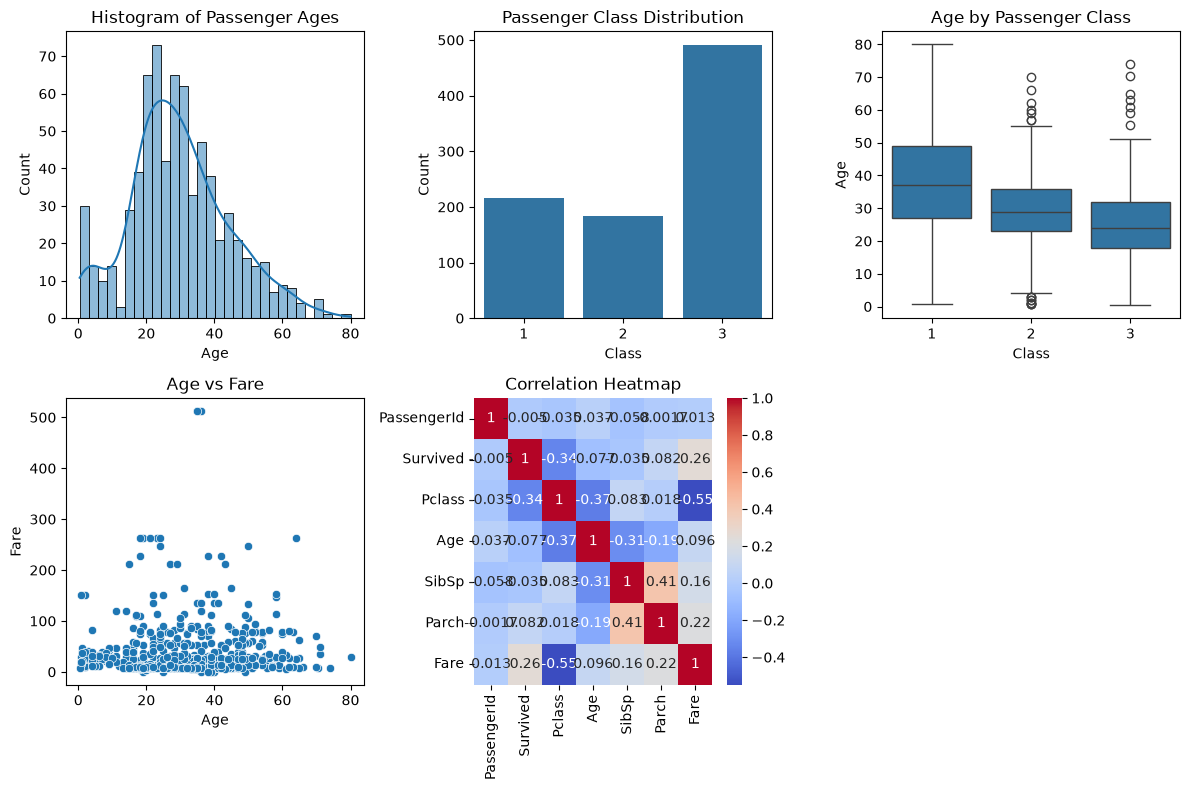

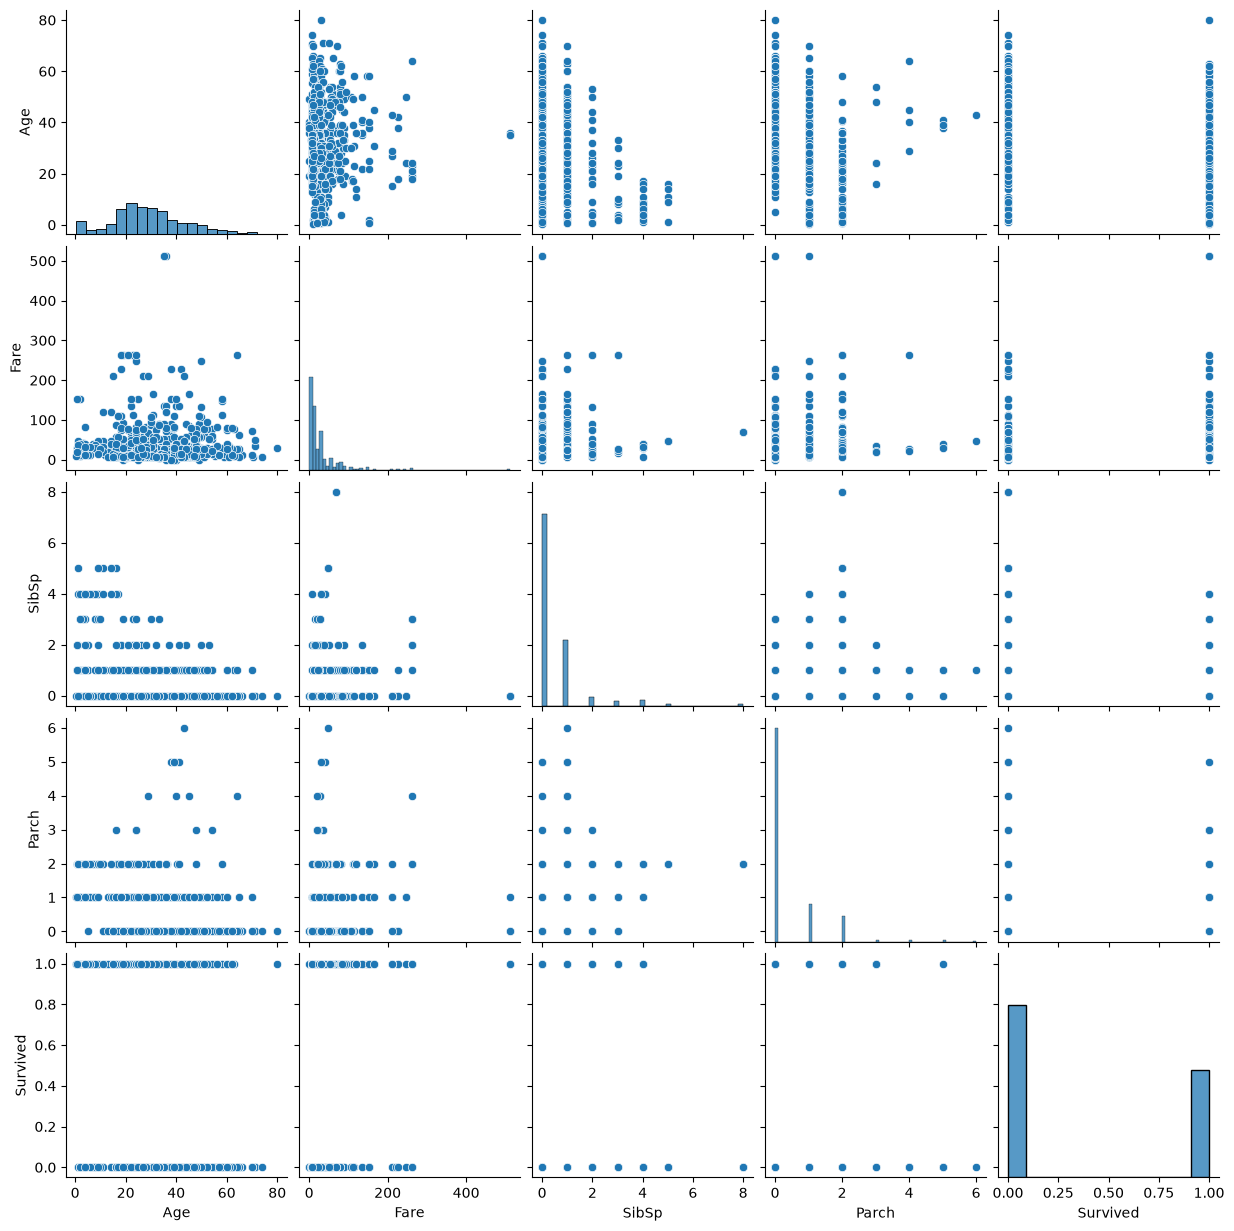

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset first
df = pd.read_csv("train.csv")

plt.figure(figsize=(12,8))

# 1. Histogram of passenger ages
plt.subplot(2,3,1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
# Interpretation: Most passengers were between 20–30 years old.

# 2. Bar chart showing passenger class distribution
plt.subplot(2,3,2)
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
# Interpretation: 3rd class had the largest number of passengers.

# 3. Boxplot of age by passenger class
plt.subplot(2,3,3)
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title("Age by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Age")
# Interpretation: 1st class passengers tended to be older than 3rd class.

# 4. Scatter plot of Age versus Fare
plt.subplot(2,3,4)
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
# Interpretation: Higher fares were generally paid by older passengers in 1st class.

# 5. Correlation Heatmap (numeric columns only)
plt.subplot(2,3,5)
corr = df.corr(numeric_only=True)   # restrict to numeric columns
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
# Interpretation: Fare and Pclass are strongly correlated; Age has weak correlation with survival.

plt.tight_layout()
plt.show()

# 6. Pairplot of selected numerical variables
sns.pairplot(df[['Age','Fare','SibSp','Parch','Survived']])
plt.show()
# Interpretation: Pairplot shows relationships among Age, Fare, SibSp, Parch, and Survived.


In [21]:
#Task 4: Statistical Analysis

In [12]:
# 1. Descriptive statistics
print("Descriptive Statistics:\n", df.describe())

# 2. Frequency distribution of survival
print("\nFrequency Distribution of Survival:\n", df['Survived'].value_counts())

# 3. Correlation analysis (numeric columns only)
corr = df.corr(numeric_only=True)

# 4. Strongest positive correlation
strongest_pos = corr.unstack().sort_values(ascending=False).iloc[1]
print("\nStrongest Positive Correlation:", strongest_pos)

# 5. Strongest negative correlation
strongest_neg = corr.unstack().sort_values().iloc[0]
print("Strongest Negative Correlation:", strongest_neg)

# 6. Example findings (to write in Markdown after running)
# - Fare and Pclass are strongly correlated
# - Female passengers had higher survival rate
# - Younger passengers and higher fare = higher survival

Descriptive Statistics:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Frequency Distribution of Survival:
 Survived
0    549


In [24]:
#Task 5: Machine Learning - Logistic Regression

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("train.csv")

# --- Data Cleaning (ensure numeric predictors) ---
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)
df.drop_duplicates(inplace=True)

# Encode categorical variables into dummy/indicator columns
df = pd.get_dummies(df, columns=['Sex','Embarked','Pclass'], drop_first=True)

# 1. Select predictors (drop target + irrelevant text columns)
X = df.drop(['Survived','Name','Ticket'], axis=1)
y = df['Survived']

# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features (important for Logistic Regression convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train_scaled, y_train)

# 5. Predict
y_pred = model.predict(X_test_scaled)

# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7932960893854749

Confusion Matrix:
 [[89 16]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

